In [94]:
# 必要なライブラリのimport
import numpy as np
from scipy import stats
from scipy.stats import poisson
import matplotlib.pyplot as plt

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns

sns.set_theme()

In [95]:
prep_data = pd.read_csv('soccer_data.csv')

prep_data.head()

,Home,Away,Home_Goals,Away_Goals
0,G-Olympus,Koban,2,3
1,Hirostar,Urawind,1,0
2,Nagomi,Shimizun,1,0
3,Savan Taurus,C-Osario,0,0
4,Sapporia,Iwana,0,0


In [96]:
prep_data.tail()

,Home,Away,Home_Goals,Away_Goals
2135,Savan Taurus,Yomoyama Mystic,2,1
2136,Shimizun,Koban,3,3
2137,Shonara,Urawind,2,1
2138,Vegalia Senda,Kashirama,0,3
2139,Obiya Arcadia,Verdix,0,1


In [97]:
# Homeチームのゴールの平均
me_Home_Goals = np.mean(prep_data['Home_Goals'])
print('Home_Goalsの平均:',me_Home_Goals)

# Awayチームのゴールの平均
me_Away_Goals = np.mean(prep_data['Away_Goals'])
print('Away_Goalsの平均:',me_Away_Goals)

Home_Goalsの平均: 1.4177570093457943
Away_Goalsの平均: 1.253271028037383


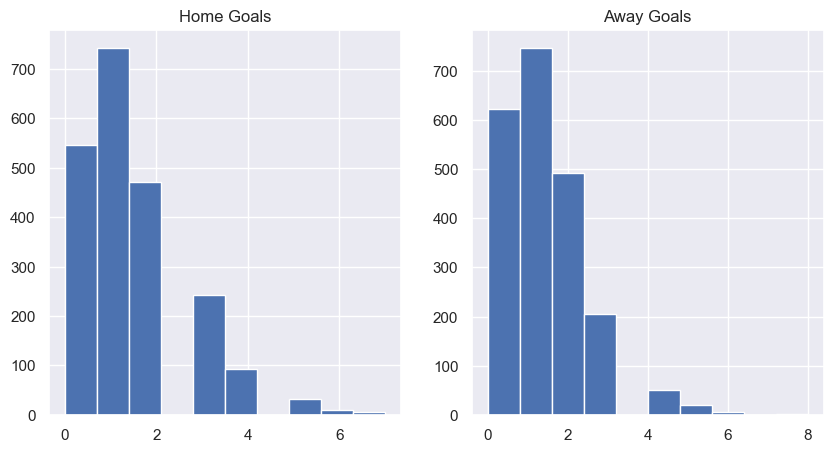

In [98]:
#全体のヒストグラム
f, axes = plt.subplots(1, 2, figsize=(10,5))

all_hist_data = pd.DataFrame(columns=['Home_Goals', 'Away_Goals'])
all_hist_data['Home_Goals'] = prep_data['Home_Goals']
all_hist_data['Away_Goals'] = prep_data['Away_Goals']

axes[0].hist(all_hist_data['Home_Goals'])
axes[1].hist(all_hist_data['Away_Goals'])

axes[0].set_title('Home Goals')
axes[1].set_title('Away Goals')
plt.show()

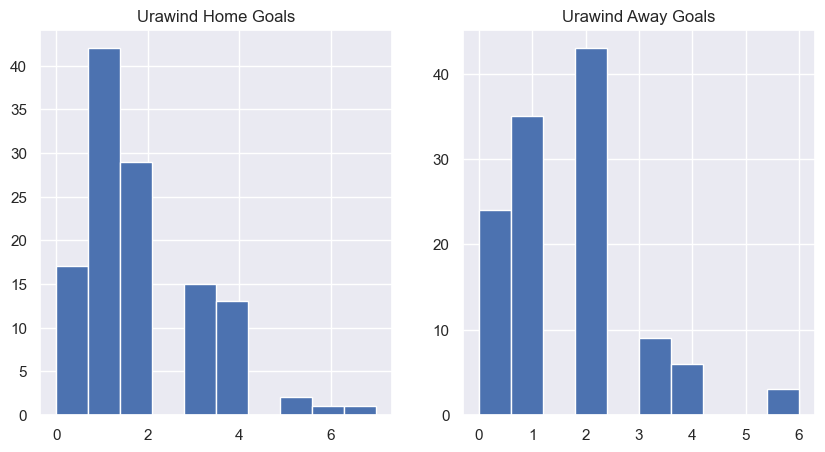

In [99]:
#Urawindのヒストグラム
f, axes = plt.subplots(1, 2, figsize=(10,5))

#データの抽出
Urawind_Home_Goals = prep_data.query('Home=="Urawind"')['Home_Goals'].dropna()
Urawind_Away_Goals = prep_data.query('Away=="Urawind"')['Away_Goals'].dropna()

axes[0].hist(Urawind_Home_Goals)
axes[1].hist(Urawind_Away_Goals)

axes[0].set_title('Urawind Home Goals')
axes[1].set_title('Urawind Away Goals')
plt.show()

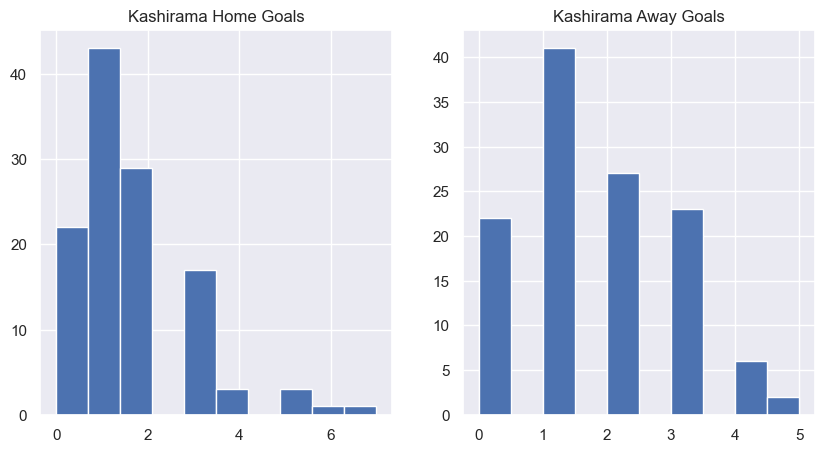

In [100]:
#Kashiramaのヒストグラム
f, axes = plt.subplots(1, 2, figsize=(10,5))

#データの抽出
Kashirama_Home_Goals = prep_data.query('Home=="Kashirama"')['Home_Goals'].dropna()
Kashirama_Away_Goals = prep_data.query('Away=="Kashirama"')['Away_Goals'].dropna()

axes[0].hist(Kashirama_Home_Goals)
axes[1].hist(Kashirama_Away_Goals)

axes[0].set_title('Kashirama Home Goals')
axes[1].set_title('Kashirama Away Goals')
plt.show()

応答変数をHome_Goalsとしてモデルを2つ作成。それぞれ、説明変数を下記のように設定。
- model_1: Away_Goals, Home, Away
- model_2: Home, Away_Goals

In [101]:
# 説明変数をAway_Goals, Home, Awayとして一般化線形モデルを作成
model_1 = smf.glm('Home_Goals ~ Away_Goals+Home+Away', data=prep_data, family=sm.families.Poisson()).fit()

In [102]:
# 説明変数をHome, Away_Goalsとして一般化線形モデルを作成
model_2 = smf.glm('Home_Goals ~ Home+Away_Goals', data=prep_data, family=sm.families.Poisson()).fit()

In [103]:
# AICを比較
print('Model-1:',model_1.aic.round(3))
print('Model-2:',model_2.aic.round(3))

Model-1: 6448.858
Model-2: 6472.639


Model-1の方が良い

In [104]:
# model_1の詳細を確認
print(model_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Home_Goals   No. Observations:                 2140
Model:                            GLM   Df Residuals:                     2087
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3171.4
Date:                Fri, 13 Mar 2026   Deviance:                       2433.7
Time:                        16:37:11   Pearson chi2:                 2.13e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.1027
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [105]:
# HomeがUrawindでAwayがKashiramaの場合のデータフレームを作成
sampleData_1 = pd.DataFrame({"Home": "Urawind", "Away": "Kashirama","Away_Goals": 0}, index=[0])
sampleData_2 = pd.DataFrame({"Home": "Urawind", "Away": "Kashirama","Away_Goals": 2}, index=[0])

print(sampleData_1)

print(sampleData_2)


      Home       Away  Away_Goals
0  Urawind  Kashirama           0
      Home       Away  Away_Goals
0  Urawind  Kashirama           2


In [106]:
# HomeがUrawindでAwayがKashiramaの場合
# Away_Goalsが0の場合のHome_Goalsの予測値
pred_1 = model_1.predict(sampleData_1)
pred_1

0    1.575325
dtype: float64

In [107]:
# HomeがUrawindでAwayがKashiramaの場合
# Away_Goalsが2の場合のHome_Goalsの予測値
pred_2 = model_1.predict(sampleData_2)
pred_2

0    1.730129
dtype: float64

In [108]:
# Homeチームが指定なしでAwayがKashiramaの場合
# KashiramaのAwayでの平均得点
me_Kashirama_Away_Goals = np.mean(Kashirama_Away_Goals)
print('KashimaraのAway_Goalsの平均（Homeチーム指定なし）:',me_Kashirama_Away_Goals)

# HomeがUrawindでAwayがKashiramaの場合
# KashiramaのAwayチームのゴールの平均
Kashirama_Away_Goals_with_Urawind = prep_data.query('Home=="Urawind" and Away=="Kashirama"')['Away_Goals'].dropna()
me_Kashirama_Away_Goals_with_Urawind = np.mean(Kashirama_Away_Goals_with_Urawind)
print('KashimaraのAway_Goalsの平均（HomeがUrawind）:',me_Kashirama_Away_Goals_with_Urawind)


KashimaraのAway_Goalsの平均（Homeチーム指定なし）: 1.6363636363636365
KashimaraのAway_Goalsの平均（HomeがUrawind）: 1.25


In [109]:
#KashimaraのAway_Goalsの平均（HomeがUrawind）をラムダとしたポアソン分布を100個生成
lambda_val = me_Kashirama_Away_Goals_with_Urawind
np.random.seed(1)
rvs_poisson = np.random.poisson(lam=lambda_val, size=100)  #ポアソン分布に従う乱数を100個生成するコード

rvs_poisson

array([2, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 2, 3, 0, 0, 1, 2, 1, 2, 3, 1, 2,
       1, 0, 1, 0, 1, 1, 2, 2, 0, 2, 3, 0, 2, 2, 4, 0, 3, 1, 2, 1, 2, 1,
       2, 2, 3, 0, 2, 4, 0, 0, 0, 0, 2, 1, 0, 3, 1, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 2, 0, 1, 3, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 0, 1, 0, 1, 3, 0,
       4, 0, 4, 1, 2, 4, 0, 0, 1, 2, 0, 1])

In [110]:
#rvs_poissonがAwayチームの得点だった場合のHomeチームの得点予想をするためのデータフレームを作成
sampleData_3 = pd.DataFrame({"Home": "Urawind", "Away": "Kashirama","Away_Goals": rvs_poisson})
print(sampleData_3)

       Home       Away  Away_Goals
0   Urawind  Kashirama           2
1   Urawind  Kashirama           1
2   Urawind  Kashirama           0
3   Urawind  Kashirama           0
4   Urawind  Kashirama           1
..      ...        ...         ...
95  Urawind  Kashirama           0
96  Urawind  Kashirama           1
97  Urawind  Kashirama           2
98  Urawind  Kashirama           0
99  Urawind  Kashirama           1

[100 rows x 3 columns]


In [111]:
# HomeがUrawindでAwayがKashiramaの場合
# Away_Goalsがrvs_possonの場合のHome_Goalsの予測値
pred_3 = model_1.predict(sampleData_3)
pred_3

0     1.730129
1     1.650914
2     1.575325
3     1.575325
4     1.650914
        ...   
95    1.575325
96    1.650914
97    1.730129
98    1.575325
99    1.650914
Length: 100, dtype: float64

別のやり方：
# 100回、繰り返し処理で予測を行う
home_preds_list = []
for i in range(len(rvs_poisson)):
    # 各行のAway_Goalsを使って予測（1件ずつ取り出す）
    input_row = pd.DataFrame({
        "Home": ["Urawind"], 
        "Away": ["Kashirama"], 
        "Away_Goals": [rvs_poisson[i]]
    })
    pred = model_1.predict(input_row).iloc[0] # 予測値を取得
    home_preds_list.append(pred)

# 繰り返し処理の完了後にndarrayへ変換
pred_3 = np.array(home_preds_list)

# これをDataFrameに結合
Home_Urawind_Away_Kashirama = sampleData_3.assign(Home_Goals_Pred=pred_3)

In [112]:
Home_Urawind_Away_Kashirama = sampleData_3.assign(Home_Goals_Pred=pred_3)
Home_Urawind_Away_Kashirama

,Home,Away,Away_Goals,Home_Goals_Pred
0,Urawind,Kashirama,2,1.730129
1,Urawind,Kashirama,1,1.650914
2,Urawind,Kashirama,0,1.575325
3,Urawind,Kashirama,0,1.575325
4,Urawind,Kashirama,1,1.650914
...,...,...,...,...
95,Urawind,Kashirama,0,1.575325
96,Urawind,Kashirama,1,1.650914
97,Urawind,Kashirama,2,1.730129
98,Urawind,Kashirama,0,1.575325


In [113]:
win = []
for i in range(len(Home_Urawind_Away_Kashirama)):
    # i行目のデータを比較 
    if Home_Urawind_Away_Kashirama.loc[i, "Home_Goals_Pred"] > Home_Urawind_Away_Kashirama.loc[i, "Away_Goals"]:
        win.append(1)
    else:
        win.append(0)

# 作成したリストを新しい列として追加
Home_Urawind_Away_Kashirama["Urawind_Win"] = win

print(Home_Urawind_Away_Kashirama.head())


      Home       Away  Away_Goals  Home_Goals_Pred  Urawind_Win
0  Urawind  Kashirama           2         1.730129            0
1  Urawind  Kashirama           1         1.650914            1
2  Urawind  Kashirama           0         1.575325            1
3  Urawind  Kashirama           0         1.575325            1
4  Urawind  Kashirama           1         1.650914            1


In [ ]:
print("HomeがUrawindでAwayがKashiramaの時のUrawindの勝率: ",Home_Urawind_Away_Kashirama["Urawind_Win"].mean())

HomeがUrawindでAwayがKashiramaの時のUrawindの勝率 0.61
